In [1]:
import os 
os.chdir('../../')
os.environ["DPM_TQDM"] = "False"
os.environ["CUDA_VISIBLE_DEVICES"]="1"

!nvidia-smi

Mon Aug 18 20:29:31 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        Off |   00000000:19:00.0 Off |                  Off |
| 87%   80C    P2            298W /  300W |   16631MiB /  24564MiB |     89%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from backbones.dit import DiT

# 사용 예
model = DiT()
print(model)

/home/scpark/miniconda3/envs/rbf/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...:   0%|          | 0/3 [00:00<?, ?it/s]An error occurred while trying to fetch /data/huggingface/DiT-XL-2-256/transformer: Error no file named diffusion_pytorch_model.safetensors found in directory /data/huggingface/DiT-XL-2-256/transformer.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading pipeline components...:  33%|███▎      | 1/3 [00:00<00:01,  1.90it/s]An error occurred while trying to fetch /data/huggingface/DiT-XL-2-256/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /data/huggingface/DiT-XL-2-256/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading pipeline co

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def display_class_images(pixel_samples, class_ids=None, figsize_per_image=3.5, display_title=""):
    samples = list(pixel_samples)
    processed = []
    for img in samples:
        if isinstance(img, Image.Image):
            arr = np.array(img)
        else:
            arr = np.array(img)
            if arr.ndim == 3 and arr.shape[0] in (1,3):
                arr = arr.transpose(1, 2, 0)
        processed.append(arr)

    n = len(processed)
    if class_ids is None:
        class_ids = list(range(n))

    fig, axes = plt.subplots(1, n, figsize=(n * figsize_per_image, figsize_per_image))
    if n == 1:
        axes = [axes]

    # 전체 제목 추가
    if display_title:
        fig.suptitle(display_title, fontsize=10, y=1.1)  # y 값을 1.02로 올려서 제목을 위로 이동
    # 플롯 레이아웃 조정: top을 낮춰서 제목과 플롯 사이에 공간 확보
    
    for ax, img_arr, lbl in zip(axes, processed, class_ids):
        ax.imshow(img_arr)
        ax.axis("off")
        ax.set_title(f"Class {lbl}", fontsize=8)

    plt.show()


In [13]:
from solvers.others.dpm_solver import DPM_Solver
from solvers.others.euler_solver import Euler_Solver

# 클래스 0–9로 설정
class_start = np.random.randint(0, 900)
#class_start = 0
class_ids = [i for i in range(class_start, class_start+100, 10)]
noise_schedule = model.get_noise_schedule()
model_fn = model.get_model_fn(noise_schedule=noise_schedule, pos_conds=class_ids, guidance_scale=3.0)
latents = model.get_noise(seeds=class_ids)


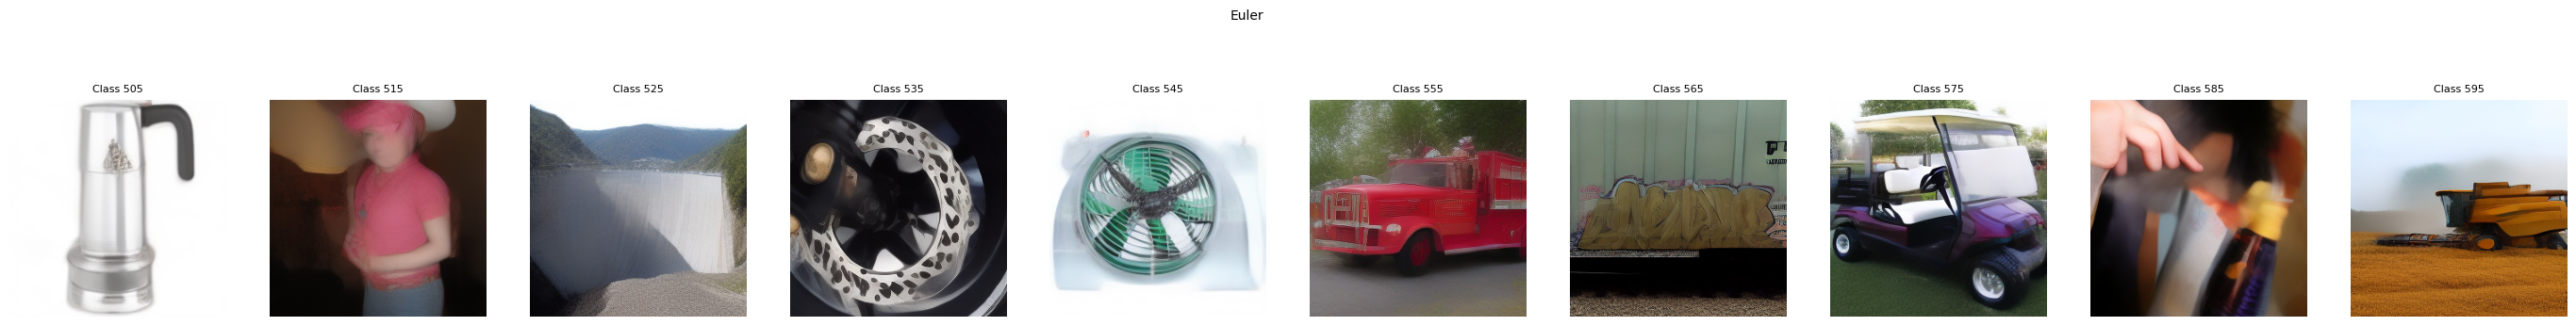

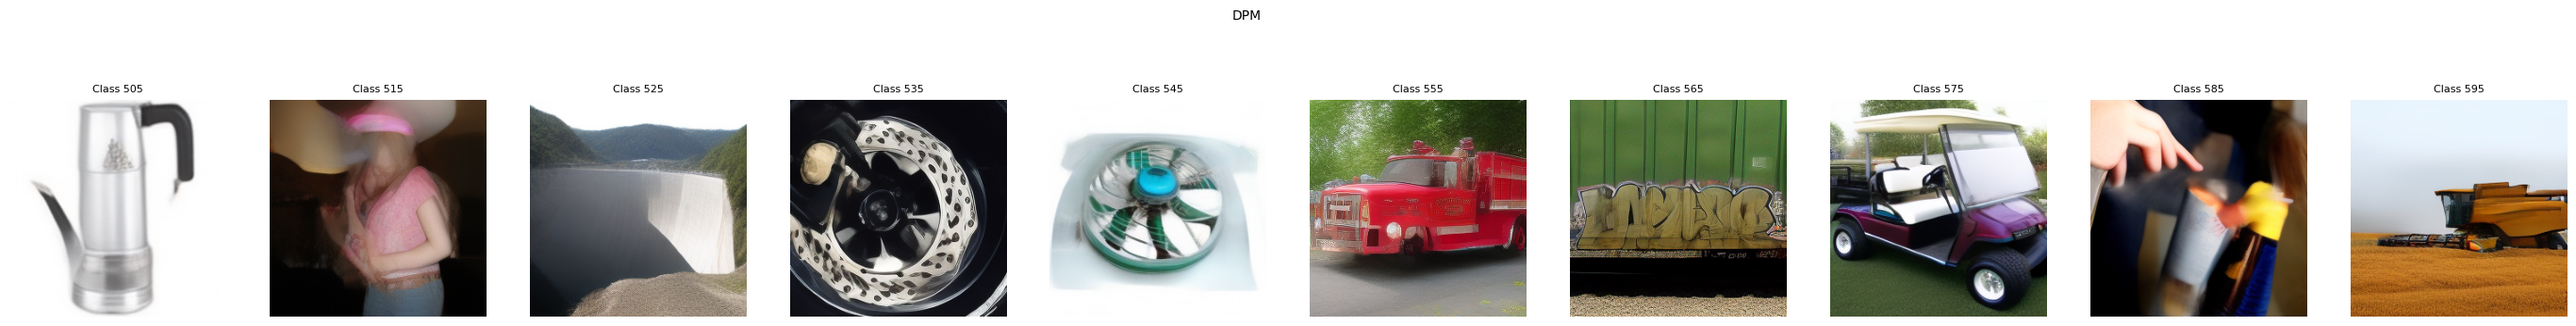

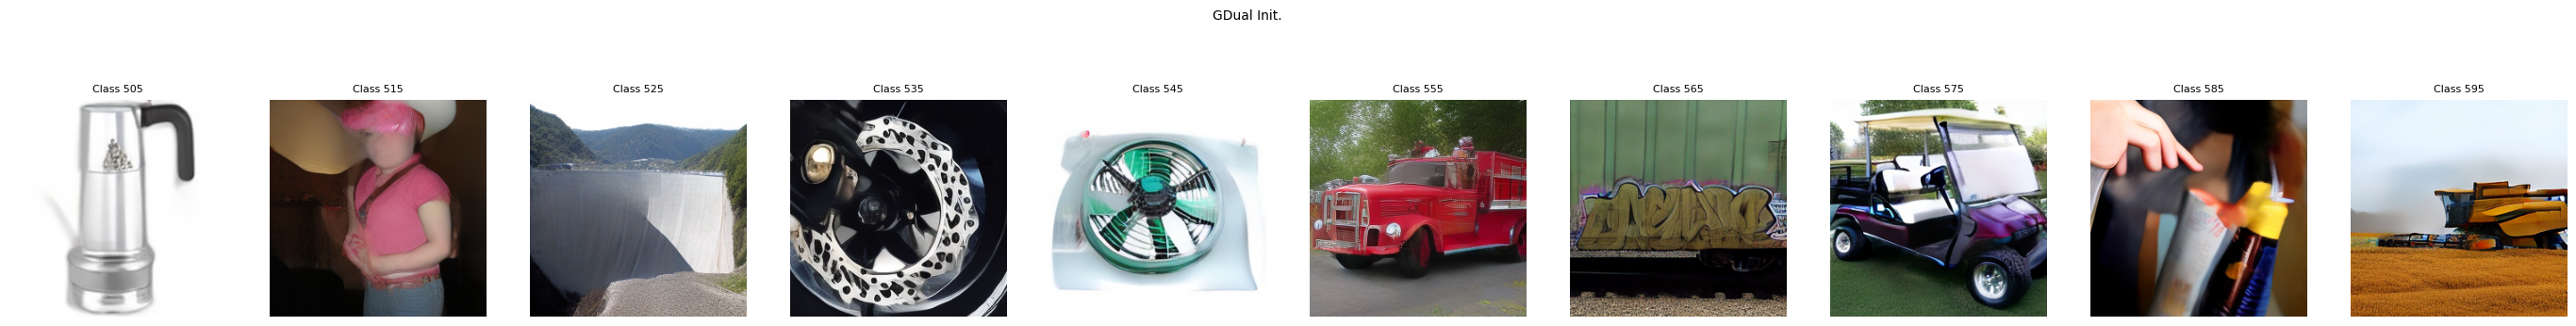

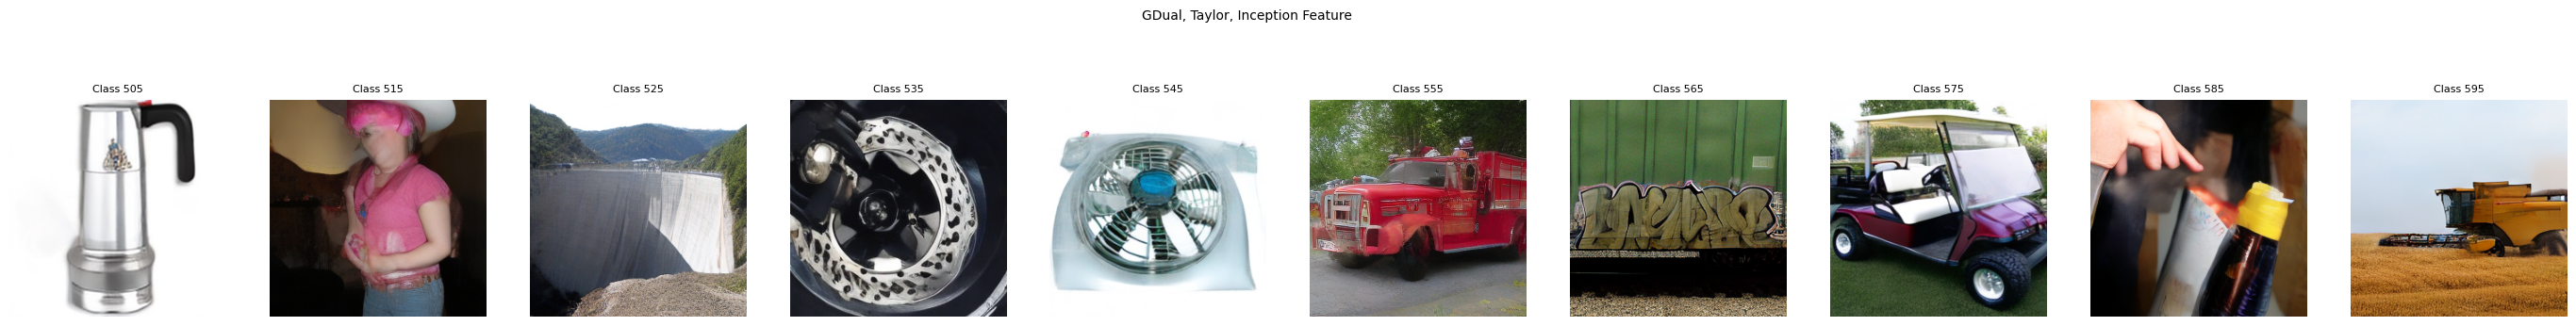

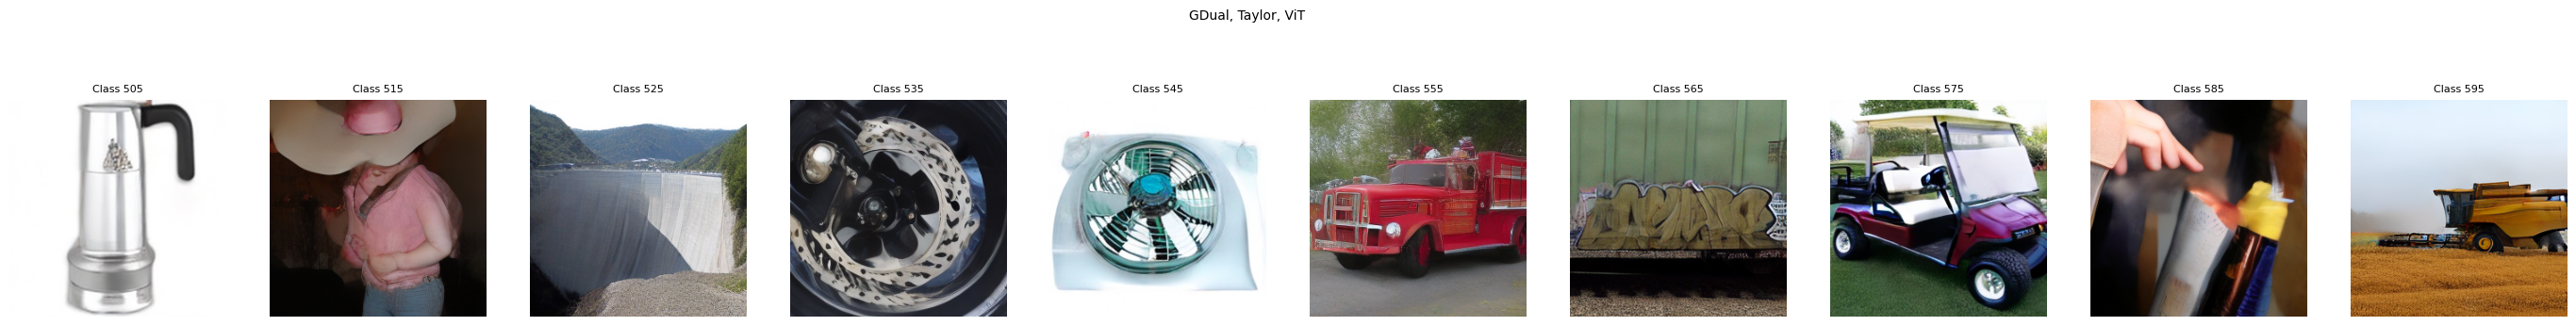

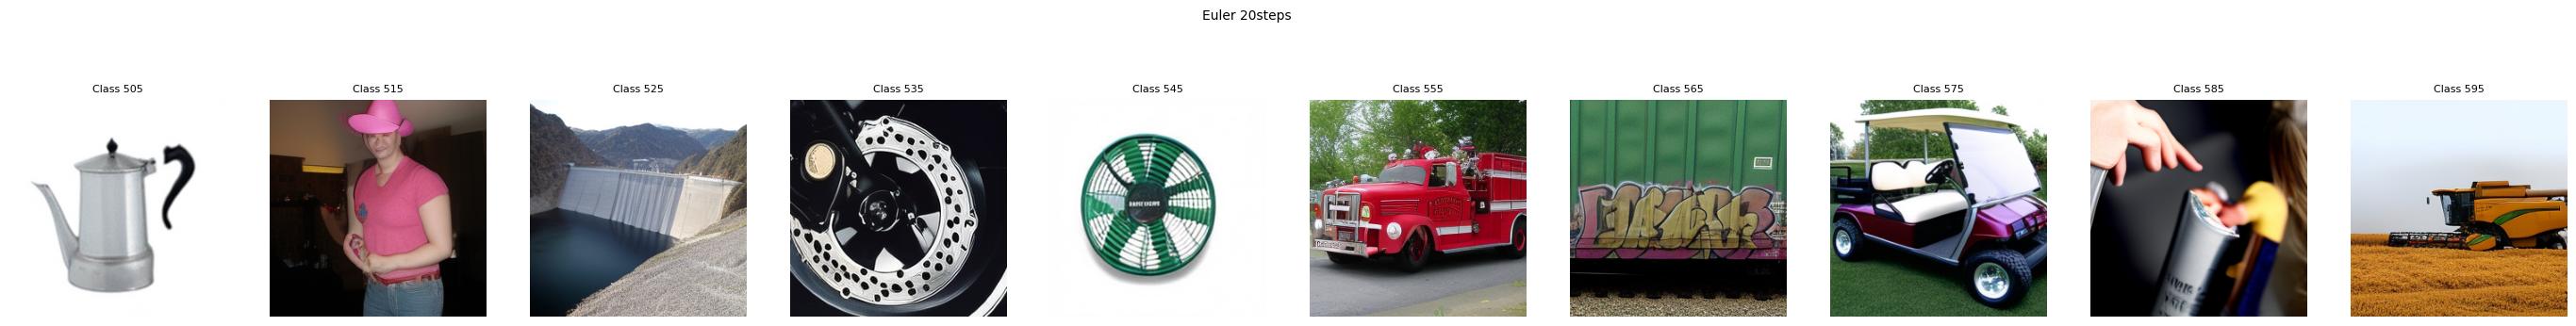

In [14]:
import torch
NFE = 5
solver = Euler_Solver(noise_schedule, steps=NFE, skip_type='time_uniform', algorithm_type="data_prediction")
euler_latents = solver.sample(latents, model_fn)['samples']
euler_samples = model.decode_vae(euler_latents)
display_class_images(euler_samples, class_ids, display_title='Euler')

solver = DPM_Solver(noise_schedule, algorithm_type="data_prediction")
euler_latents = solver.sample(model_fn, latents, steps=NFE, skip_type='time_uniform')
euler_samples = model.decode_vae(euler_latents)
display_class_images(euler_samples, class_ids, display_title='DPM')

from solvers.taylor.solver.gdual_solver import GDual_Solver
from solvers.taylor.transform.logaffine_transform import LogAffineTransform
from solvers.taylor.extractor.table_extractor import Extractor

noise_schedule = model.get_noise_schedule()
extractor = Extractor()
transform = LogAffineTransform(gamma_push=True, gamma_max=2, tau_offset=1, kappa_max=2, eps=1e-2)
solver = GDual_Solver(
    noise_schedule,
    steps=5,
    transform=transform,
    param_extractor=extractor,
    skip_type="time_uniform",
    pred_order=1,
    corr_order=2,
    order1_kappa=True,
    order2_kappa=True,
    use_corrector=True,
    time_learning=True,
    train_mode=True
).to(model.device)

with torch.no_grad():
    euler_latents = solver.sample(latents, model_fn)
    euler_samples = model.decode_vae(euler_latents)
display_class_images(euler_samples, class_ids, display_title='GDual Init.')

pt_file = 'logs/CFG4.0/0818-2:Taylor,log-affine,p1c2,kappa/step_00002500.pt'
state_dict = torch.load(pt_file, map_location='cpu')['solver_state_dict']
solver.load_state_dict(state_dict, strict=True)
with torch.no_grad():
    euler_latents = solver.sample(latents, model_fn)
    euler_samples = model.decode_vae(euler_latents)
display_class_images(euler_samples, class_ids, display_title='GDual, Taylor, Inception Feature')

pt_file = 'logs/CFG4.0/0818-6:Taylor,log-affine,p1c2,kappa,ViT/step_00000600.pt'
state_dict = torch.load(pt_file, map_location='cpu')['solver_state_dict']
solver.load_state_dict(state_dict, strict=True)
with torch.no_grad():
    euler_latents = solver.sample(latents, model_fn)
    euler_samples = model.decode_vae(euler_latents)
display_class_images(euler_samples, class_ids, display_title='GDual, Taylor, ViT')


NFE = 20
solver = Euler_Solver(noise_schedule, steps=NFE, skip_type='time_uniform', algorithm_type="data_prediction")
euler_latents = solver.sample(latents, model_fn)['samples']
euler_samples = model.decode_vae(euler_latents)
display_class_images(euler_samples, class_ids, display_title='Euler 20steps')

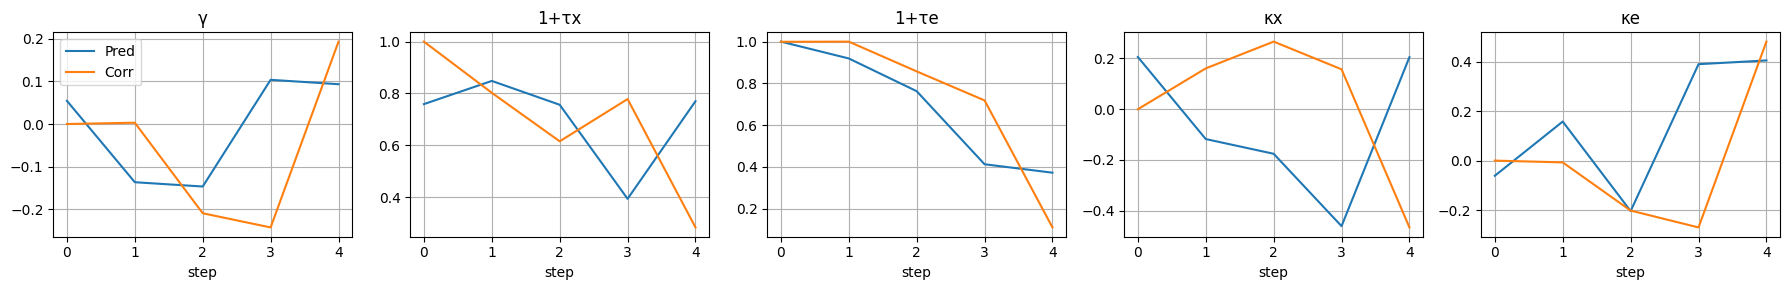

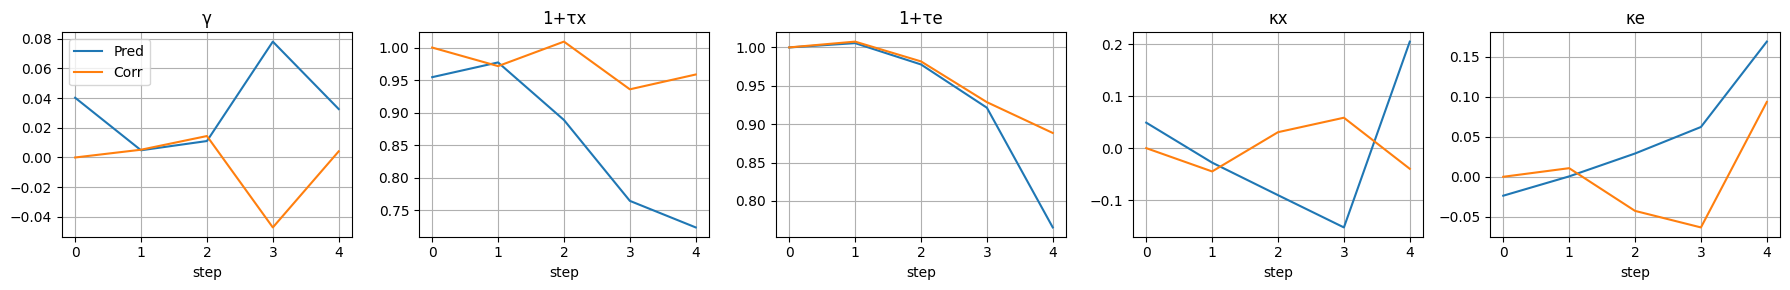

In [15]:
import torch, numpy as np, matplotlib.pyplot as plt

PATHS  = ['logs/CFG4.0/0818-2:Taylor,log-affine,p1c2,kappa/step_00002500.pt',
          'logs/CFG4.0/0818-6:Taylor,log-affine,p1c2,kappa,ViT/step_00000600.pt'
         ]

for PATH in PATHS:
    tab   = torch.load(PATH, map_location='cpu')['solver_state_dict']['param_extractor.table'].float().numpy()  # [S,2,P]
    x     = np.arange(tab.shape[0])

    fig, ax = plt.subplots(1, 5, figsize=(18, 3), sharex=True)
    params = [
        (0, 'γ',     lambda a: a),
        (1, '1+τx',  lambda a: 1.0 + a),
        (2, '1+τe',  lambda a: 1.0 + a),
        (3, 'κx',    lambda a: a),
        (4, 'κe',    lambda a: a),
    ]

    for k, (idx, title, f) in enumerate(params):
        ax[k].plot(x, f(tab[:, 0, idx]), label='Pred' if k==0 else None)
        ax[k].plot(x, f(tab[:, 1, idx]), label='Corr' if k==0 else None)
        ax[k].set_title(title); ax[k].set_xlabel('step'); ax[k].grid(True)

    ax[0].legend(); fig.tight_layout(); plt.show()
    # 필요하면 κ 축을 로그스케일로:
    # for i in (3,4): ax[i].set_yscale('log')
